Q5: **PYTHON**
Regression: predict DefectRate (or DefectCount) from sensor variables +
EnergyConsumption + ProductionUnits. Include feature importance.


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_excel("/content/QUALITY & DEFECT REDUCTION (Original).xlsx")
df


,Timestamp,MachineID,Plant,Temperature,Vibration,Pressure,EnergyConsumption,ProductionUnits,DefectCount,MaintenanceFlag
0,2025-01-01 00:00:00,142,Plant_B,77.474270,2.604480,23.438160,315.443998,52,4,0
1,2025-01-01 01:00:00,124,Plant_C,72.435288,6.240213,30.236166,300.579876,89,1,0
2,2025-01-01 02:00:00,103,Plant_A,59.063863,6.470758,32.778778,240.961506,194,0,0
3,2025-01-01 03:00:00,108,Plant_C,63.859148,3.646682,26.077120,206.954154,190,2,0
4,2025-01-01 04:00:00,100,Plant_B,76.799275,5.261242,33.432417,259.130150,173,8,1
...,...,...,...,...,...,...,...,...,...,...
19995,2027-04-14 03:00:00,121,Plant_C,67.194241,4.019728,26.396335,220.890014,180,3,0
19996,2027-04-14 04:00:00,147,Plant_A,77.822169,4.442125,25.225431,261.781322,131,1,1
19997,2027-04-14 05:00:00,149,Plant_A,72.438019,6.871999,28.070647,255.068111,67,2,0
19998,2027-04-14 06:00:00,125,Plant_A,67.659163,6.618082,27.092229,174.123973,57,5,0


In [ ]:
df["DefectRate"] = df["DefectCount"] / df["ProductionUnits"]
df["DefectRate"] = df["DefectRate"].fillna(0)


In [ ]:
features = ["Temperature", "Vibration", "Pressure",
            "EnergyConsumption", "ProductionUnits"]

X = df[features]
y = df["DefectRate"]     # or df["DefectCount"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)


RMSE: 0.0183478080385364
R2 Score: 0.2408634394452689


In [ ]:
importance = model.feature_importances_

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)
print(feat_imp)


ProductionUnits      0.387200
EnergyConsumption    0.154616
Vibration            0.154339
Temperature          0.154131
Pressure             0.149714
dtype: float64


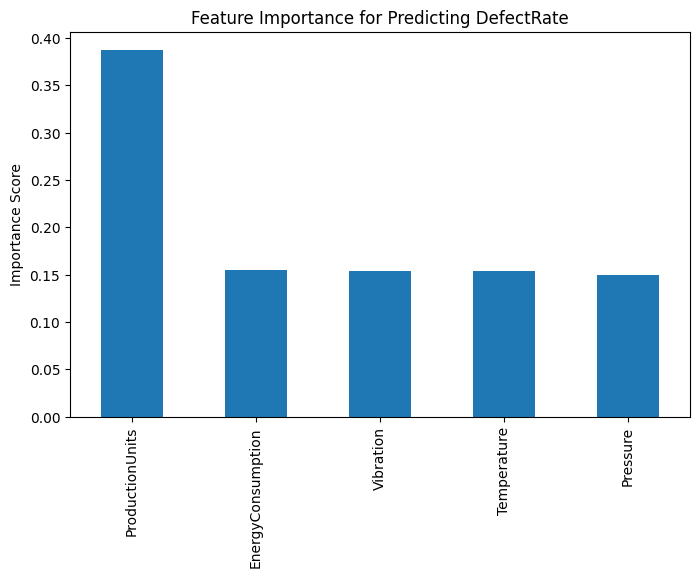

In [ ]:
plt.figure(figsize=(8,5))
feat_imp.plot(kind="bar")
plt.title("Feature Importance for Predicting DefectRate")
plt.ylabel("Importance Score")
plt.show()


Q6: PYTHON
**Clustering:** cluster MachineID based on mean DefectRate, mean Vibration,
mean Temperature, mean Pressure. Label clusters as “High Defect / High
Vibration” etc. Output cluster summary.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [ ]:
df=pd.read_excel(r"/content/QUALITY & DEFECT REDUCTION (Original).xlsx")
print(df.head())

            Timestamp  MachineID    Plant  Temperature  Vibration   Pressure  \
0 2025-01-01 00:00:00        142  Plant_B    77.474270   2.604480  23.438160   
1 2025-01-01 01:00:00        124  Plant_C    72.435288   6.240213  30.236166   
2 2025-01-01 02:00:00        103  Plant_A    59.063863   6.470758  32.778778   
3 2025-01-01 03:00:00        108  Plant_C    63.859148   3.646682  26.077120   
4 2025-01-01 04:00:00        100  Plant_B    76.799275   5.261242  33.432417   

   EnergyConsumption  ProductionUnits  DefectCount  MaintenanceFlag  
0         315.443998               52            4                0  
1         300.579876               89            1                0  
2         240.961506              194            0                0  
3         206.954154              190            2                0  
4         259.130150              173            8                1  


In [ ]:
df.columns

Index(['Timestamp', 'MachineID', 'Plant', 'Temperature', 'Vibration',
       'Pressure', 'EnergyConsumption', 'ProductionUnits', 'DefectCount',
       'MaintenanceFlag'],
      dtype='object')

In [ ]:
df["DefectRate"] = df["DefectCount"] / df["ProductionUnits"]
df["DefectRate"] = df["DefectRate"].fillna(0)
machine_avg = df.groupby("MachineID").agg({
    "DefectRate": "mean",
    "Vibration": "mean",
    "Temperature": "mean",
    "Pressure": "mean"
}).reset_index()

In [ ]:
features = machine_avg[
    ["DefectRate","Vibration","Temperature","Pressure"]
]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)

machine_avg["Cluster"] = kmeans.fit_predict(scaled_features)


In [ ]:
cluster_summary = machine_avg.groupby("Cluster").agg({
    "DefectRate":"mean",
    "Vibration":"mean",
    "Temperature":"mean",
    "Pressure":"mean",
    "MachineID":"count"
}).rename(columns={"MachineID":"MachineCount"})


In [ ]:
def label_cluster(row):

    label = []

    if row["DefectRate"] > cluster_summary["DefectRate"].mean():
        label.append("High Defect")
    else:
        label.append("Low Defect")

    if row["Vibration"] > cluster_summary["Vibration"].mean():
        label.append("High Vibration")
    else:
        label.append("Low Vibration")

    return " / ".join(label)

cluster_summary["Label"] = cluster_summary.apply(label_cluster, axis=1)


In [ ]:
print(cluster_summary)


         DefectRate  Vibration  Temperature   Pressure  MachineCount  \
Cluster                                                                
0          0.027661   5.004555    70.566061  30.006705            17   
1          0.027693   5.000364    69.842391  29.884812            27   
2          0.028874   4.973216    69.660755  30.254396             6   

                               Label  
Cluster                               
0        Low Defect / High Vibration  
1        Low Defect / High Vibration  
2        High Defect / Low Vibration  


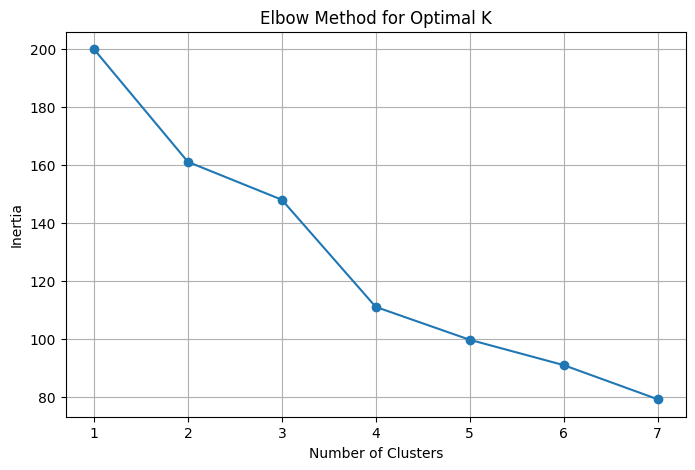

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,8), inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


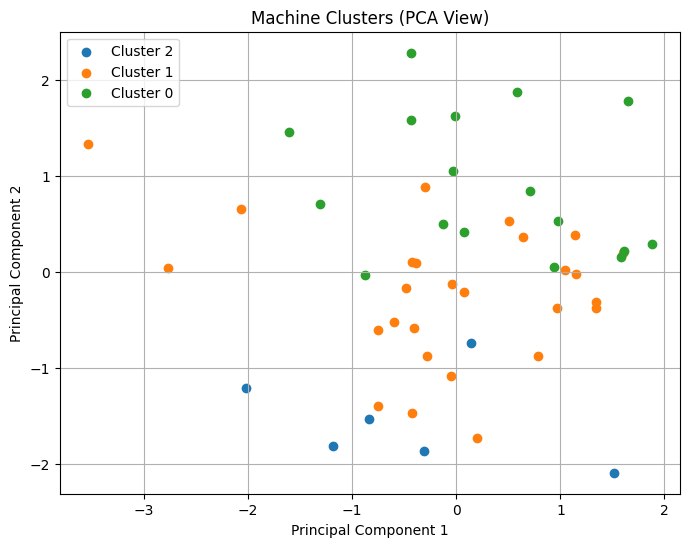

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

machine_avg["PCA1"] = pca_features[:,0]
machine_avg["PCA2"] = pca_features[:,1]

plt.figure(figsize=(8,6))

for cluster in machine_avg["Cluster"].unique():
    subset = machine_avg[machine_avg["Cluster"] == cluster]
    plt.scatter(subset["PCA1"], subset["PCA2"], label=f"Cluster {cluster}")

plt.title("Machine Clusters (PCA View)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()


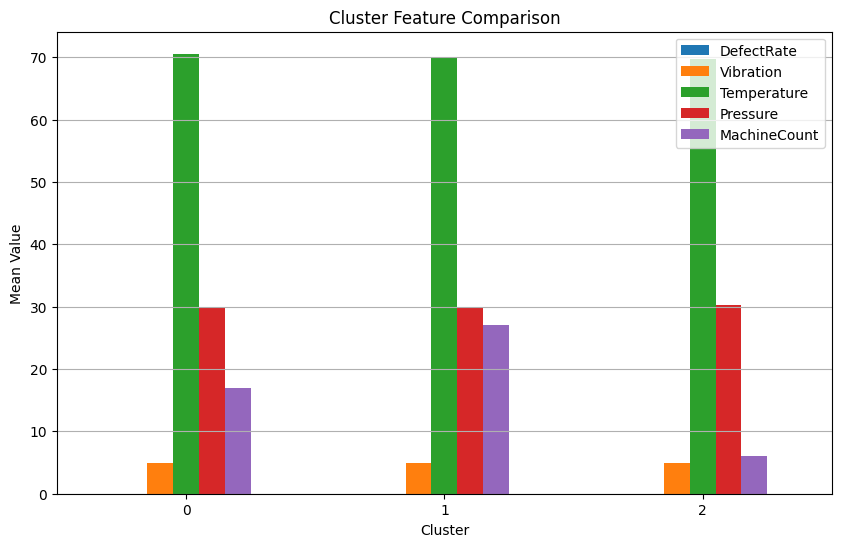

In [ ]:
cluster_summary.plot(kind="bar", figsize=(10,6))

plt.title("Cluster Feature Comparison")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()
